# Basic concepts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import convolve, gaussian_laplace
from skimage import data
from skimage.metrics import peak_signal_noise_ratio
from skimage.exposure import histogram, rescale_intensity
from skimage.io import imread
from skimage.measure import label, regionprops, regionprops_table
from skimage.filters import median, gaussian, threshold_otsu, threshold_li, threshold_triangle
from scipy.ndimage import binary_fill_holes
from skimage.morphology import erosion, dilation, disk
from iaf.color import to_composite, Color, get_hilo_cmap
from iaf.plot import imshow, show_labels
from iaf.plot.validation import plot_background_subtraction_control
from iaf.process import subtract_background
from iaf.morph.watershed import estimate_object_sizes, separate_neighboring_objects
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from iaf.notebook import init_style
init_style()

## Data types

In [2]:
int_types = [np.uint8, np.int8, np.uint16, np.int16, np.uint32, np.int32, np.uint64, np.int64, int] # int is the (only) Python integer data type
for int_type in int_types:
    print(f"{str(int_type):>24}: range = ({np.iinfo(int_type).min:>11} -> {np.iinfo(int_type).max:>11})")

   <class 'numpy.uint8'>: range = (          0 ->         255)
    <class 'numpy.int8'>: range = (       -128 ->         127)
  <class 'numpy.uint16'>: range = (          0 ->       65535)
   <class 'numpy.int16'>: range = (     -32768 ->       32767)
  <class 'numpy.uint32'>: range = (          0 ->  4294967295)
   <class 'numpy.int32'>: range = (-2147483648 ->  2147483647)
  <class 'numpy.uint64'>: range = (          0 -> 18446744073709551615)
   <class 'numpy.int64'>: range = (-9223372036854775808 -> 9223372036854775807)
           <class 'int'>: range = (-9223372036854775808 -> 9223372036854775807)


In [3]:
float_types = [np.float16, np.float32, np.float64, float] # float is the (only) Python floating-point data type
for float_type in float_types:
    print(f"{str(float_type):>24}: range = ({np.finfo(float_type).min:>24} -> {np.finfo(float_type).max:>24}), resolution (at 1.0) = {np.finfo(float_type).resolution:>21} (significant digits = {np.finfo(float_type).precision})")

 <class 'numpy.float16'>: range = (                -65504.0 ->                  65504.0), resolution (at 1.0) = 0.0010004043579101562 (significant digits = 3)
 <class 'numpy.float32'>: range = ( -3.4028234663852886e+38 ->   3.4028234663852886e+38), resolution (at 1.0) = 9.999999974752427e-07 (significant digits = 6)
 <class 'numpy.float64'>: range = (-1.7976931348623157e+308 ->  1.7976931348623157e+308), resolution (at 1.0) =                 1e-15 (significant digits = 15)
         <class 'float'>: range = (-1.7976931348623157e+308 ->  1.7976931348623157e+308), resolution (at 1.0) =                 1e-15 (significant digits = 15)


In [4]:
a = np.uint8(10)
b = np.uint8(20)
print(a - b)

c = np.uint8(250)
print(c + a)

246
4


/tmp/ipykernel_78578/790231149.py:3: RuntimeWarning: overflow encountered in scalar subtract
  print(a - b)
/tmp/ipykernel_78578/790231149.py:6: RuntimeWarning: overflow encountered in scalar add
  print(c + a)


In [5]:
a = np.float32(1000)

b = a + np.float32(1e-4)
print(f"{a} == {b}: {b == a}")  # 1e-4 is larger than precision

c = a + np.float32(1e-5)
print(f"{a} == {c}: {c == a}")  # # 1e-5 is smaller than precision

1000.0 == 1000.0001220703125: False
1000.0 == 1000.0: True


In [6]:
# When applying operations that may overflow, play it defensively
e = np.uint8([10, 20, 30])
f = np.uint8([20, 10, 15])
g = e.astype(np.float32) - f
print(g)

# Set negative values to 0
g[g < 0] = 0

# Cast back
g = g.astype(np.uint8)
print(g)

[-10.  10.  15.]
[ 0 10 15]


## Colors

### RGB images

In [7]:
# To read an image, we can use skimage.io.imread. Here we use a demo image.
img_rgb = data.coffee()

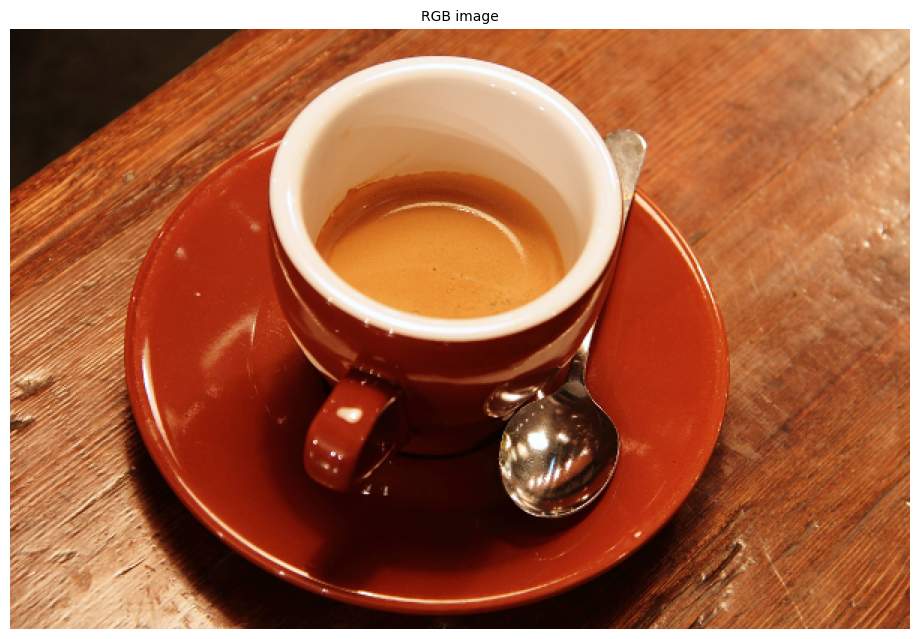

In [8]:
imshow(img_rgb, title="RGB image")

In [9]:
img_rgb.shape

(400, 600, 3)

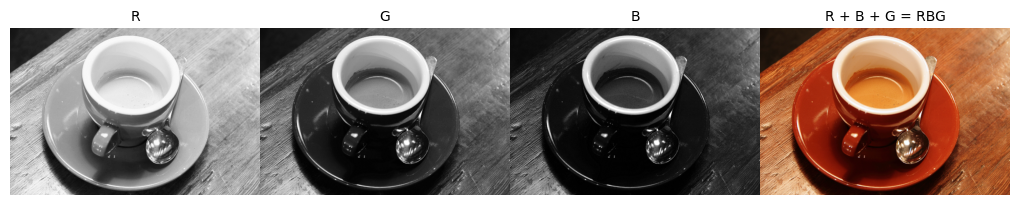

In [10]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
imshow(img_rgb[:, :, 0], ax=ax1, title="R")
imshow(img_rgb[:, :, 1], ax=ax2, title="G")
imshow(img_rgb[:, :, 2], ax=ax3, title="B")
imshow(img_rgb, ax=ax4, title="R + B + G = RBG")

### Multi-channel, intensity images

In [11]:
img = imread("Rat_Hippocampal_Neuron.tif")

In [12]:
img.shape

(5, 512, 512)

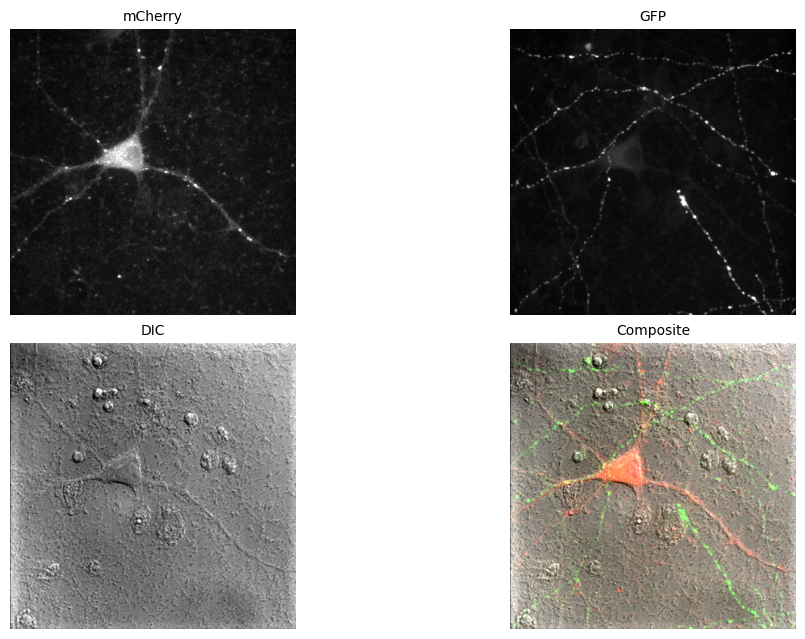

In [13]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
imshow(img[0], cmap="gray", ax=ax1, auto_stretch=True, clip_percentile=0.1, title="mCherry")
imshow(img[2], cmap="gray", ax=ax2, auto_stretch=True, clip_percentile=0.1, title="GFP")
imshow(img[4], cmap="gray", ax=ax3, auto_stretch=True, clip_percentile=0.1, title="DIC")
imshow(to_composite(images=(img[0], img[2], img[4]), colors=(Color.Red, Color.Green, Color.Gray)), ax=ax4, auto_stretch=True, clip_percentile=0.1, title="Composite")

## Image histogram

In [14]:
img = imread("FITC.tif")

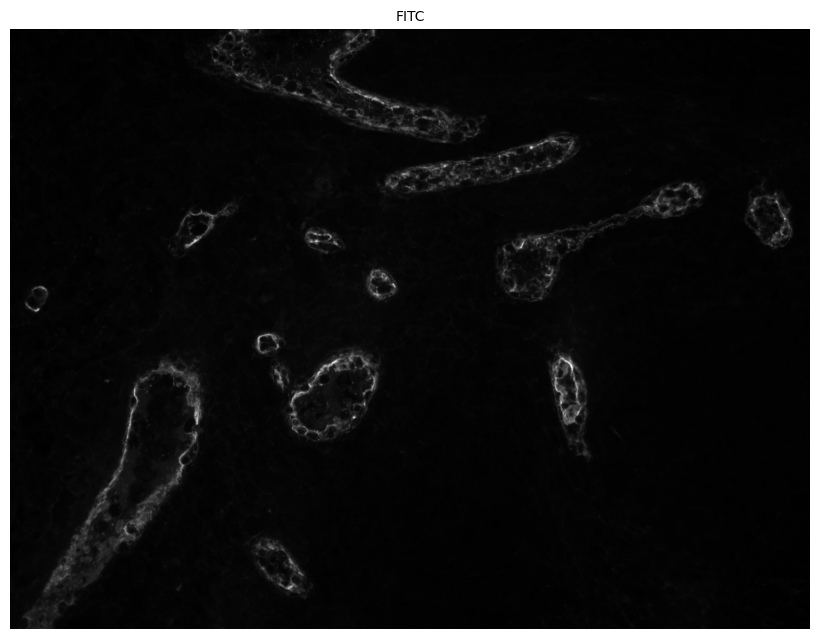

In [15]:
imshow(img, auto_stretch=True, title="FITC")

In [16]:
n, b = histogram(img, source_range="dtype")

In [17]:
norm_log_n = np.log(1.0 + n)

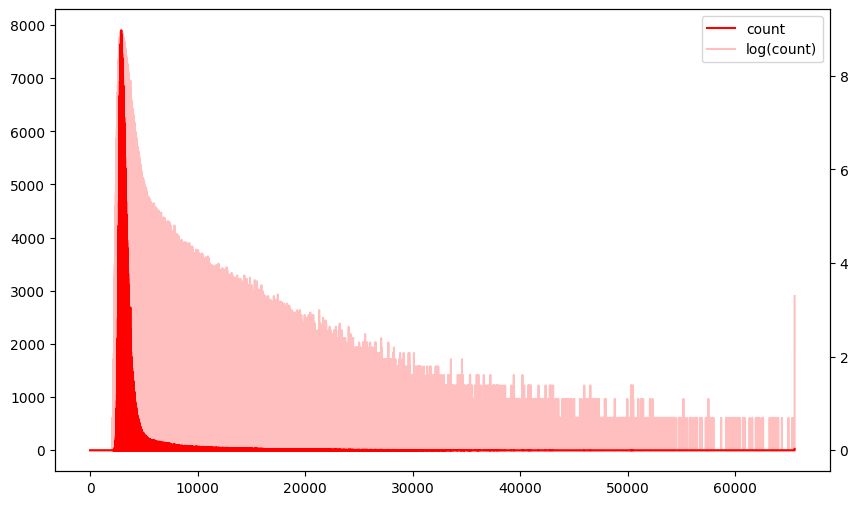

In [18]:
ax1 = plt.subplot()
l1, = ax1.plot(b, n, color="r")
ax2 = ax1.twinx()
l2, = ax2.plot(b, norm_log_n, color="r", alpha=0.25)
plt.legend([l1, l2], ["count", "log(count)"]);

## Intensity stretching

In [19]:
vmin, vmax = np.percentile(img, (5, 95))
img_s = rescale_intensity(img, (vmin, vmax))

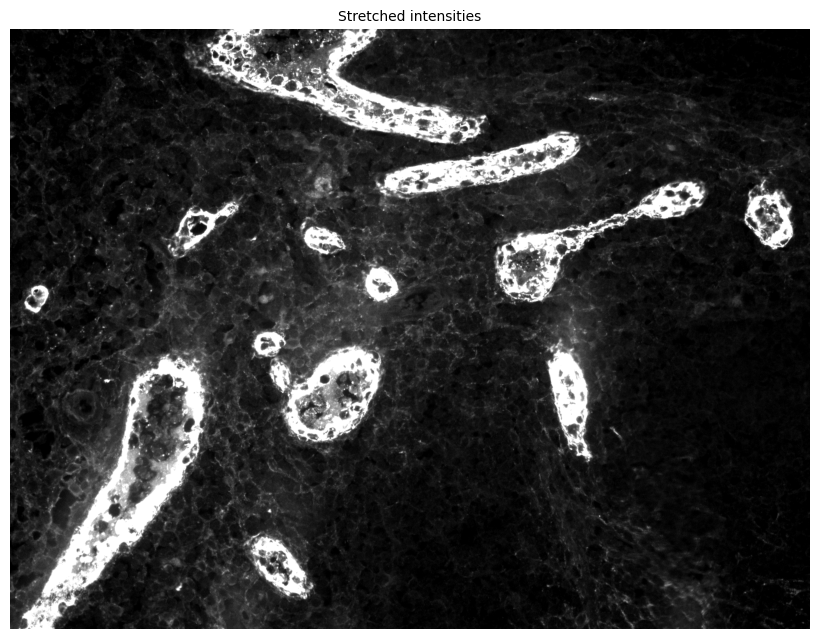

In [20]:
imshow(img_s, title="Stretched intensities")

In [21]:
n_s, b_s = histogram(img_s, source_range="dtype")

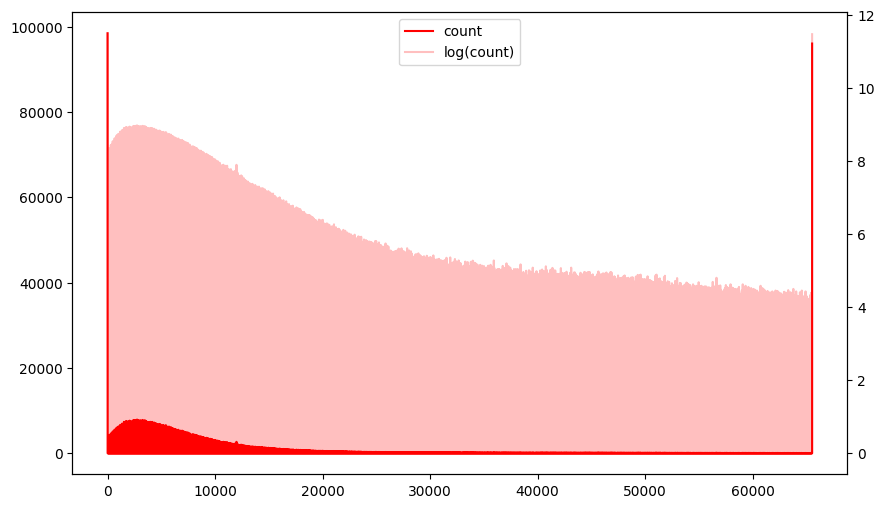

In [22]:
ax1 = plt.subplot()
l1, = ax1.plot(b_s, n_s, color="r")
ax2 = ax1.twinx()
l2, = ax2.plot(b_s, np.log(1.0 + n_s), color="r", alpha=0.25)
plt.legend([l1, l2], ["count", "log(count)"]);

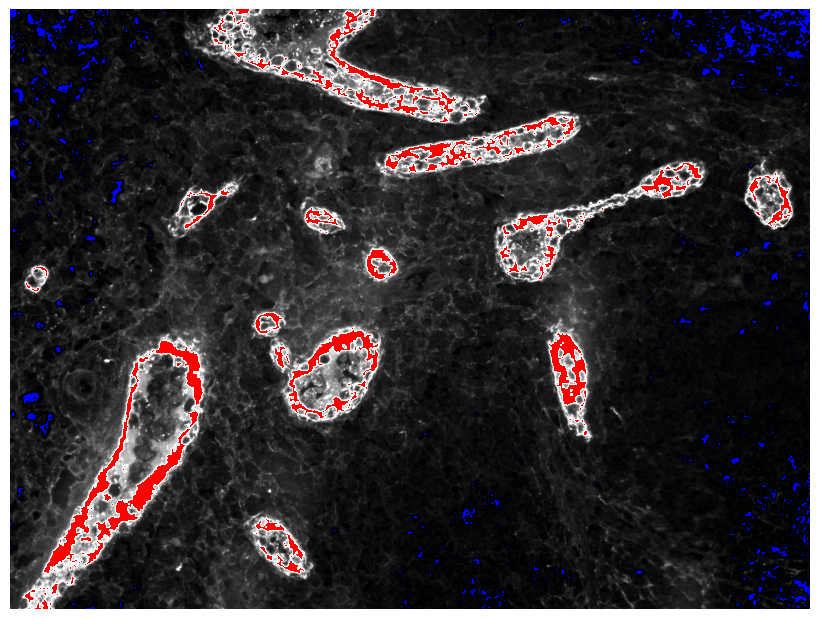

In [23]:
imshow(img_s, cmap=get_hilo_cmap(65535))

## Filters

### Convolution

In [24]:
img = imread("actin.tif")

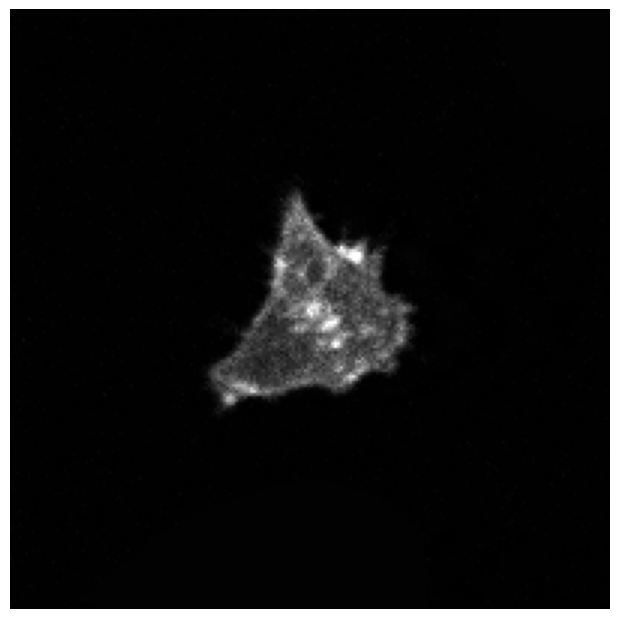

In [25]:
imshow(img)

#### Average filter

In [26]:
k_5x5 = 1/25 * np.array([
    [ 1.0, 1.0, 1.0, 1.0, 1.0], 
    [ 1.0, 1.0, 1.0, 1.0, 1.0], 
    [ 1.0, 1.0, 1.0, 1.0, 1.0], 
    [ 1.0, 1.0, 1.0, 1.0, 1.0], 
    [ 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

In [27]:
k_5x5

array([[0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04]], dtype=float32)

In [28]:
img_f_5x5 = convolve(img, k_5x5)

In [29]:
k_9x9 = 1/81 * np.ones((9, 9), dtype=np.float32)

In [30]:
img_f_9x9 = convolve(img, k_9x9)

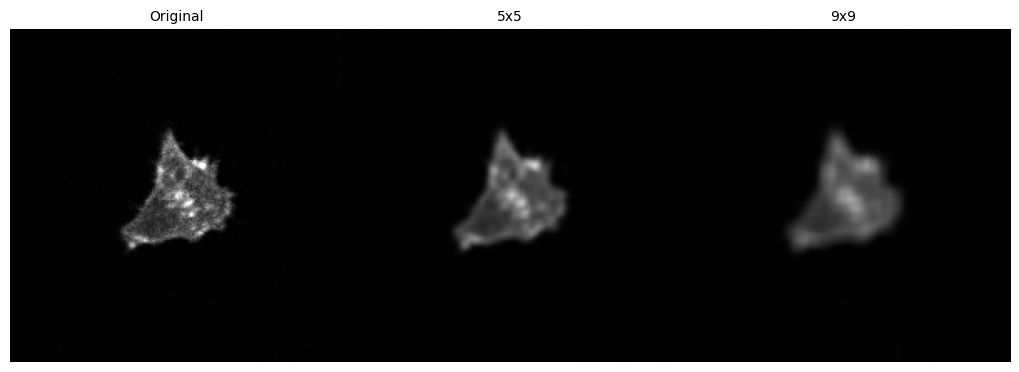

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img, ax=ax1, title="Original")
imshow(img_f_5x5, ax=ax2, title="5x5")
imshow(img_f_9x9, ax=ax3, title="9x9")

#### Gaussian filter

In [32]:
def gauss_2d(size, sigma):
    cy = size[0] // 2
    cx = size[1] // 2
    out = np.zeros(size, dtype=np.float32)
    for y in range(-cy, cy + 1):
        for x in range(-cx, cx + 1):
            r = y + cy
            c = x + cx
            out[r, c] = np.exp(-1.0 * ((x ** 2 + y ** 2) / (2 * sigma ** 2)))
    return out

In [33]:
k = gauss_2d(size=(5, 5), sigma=1)
k

array([[0.01831564, 0.082085  , 0.13533528, 0.082085  , 0.01831564],
       [0.082085  , 0.36787945, 0.60653067, 0.36787945, 0.082085  ],
       [0.13533528, 0.60653067, 1.        , 0.60653067, 0.13533528],
       [0.082085  , 0.36787945, 0.60653067, 0.36787945, 0.082085  ],
       [0.01831564, 0.082085  , 0.13533528, 0.082085  , 0.01831564]],
      dtype=float32)

We can use the kernel `k` returned by `gauss_2d()` with `convolve()` as we did before. In practice, we will use `skimage.filters.gaussian` instead.

In [34]:
img_f_gs1 = gaussian(img, sigma=1.0)
img_f_gs3 = gaussian(img, sigma=3.0)

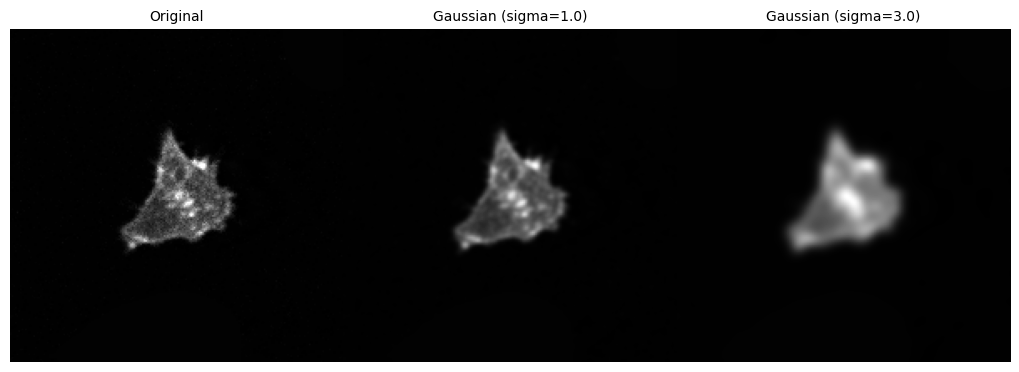

In [35]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img, ax=ax1, title="Original")
imshow(img_f_gs1, ax=ax2, title="Gaussian (sigma=1.0)")
imshow(img_f_gs3, ax=ax3, title="Gaussian (sigma=3.0)")

#### Image derivatives

In [36]:
k_sx = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

In [37]:
k_sy = k_sx.T

In [38]:
img_f_sx = convolve(img.astype(np.float32), k_sx)
img_f_sy = convolve(img.astype(np.float32), k_sy)

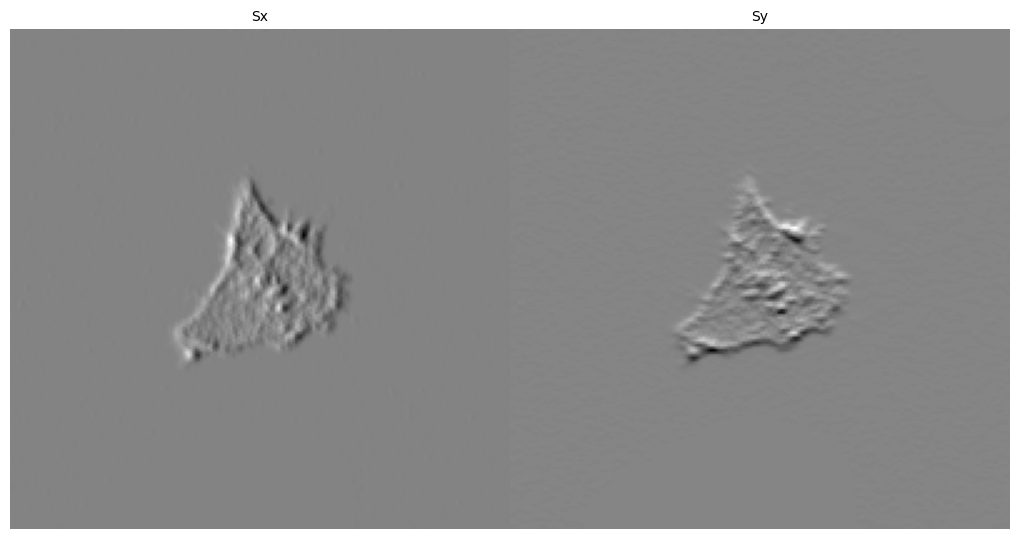

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2)
imshow(img_f_sx, ax=ax1, title="Sx")
imshow(img_f_sy, ax=ax2, title="Sy")

In [40]:
img = imread("blobs.tif")

In [41]:
k_lp = np.array([
    [ 1,  1,  1],
    [ 1, -8,  1],
    [ 1,  1,  1]
], dtype=np.float32)

In [42]:
img_f_lp = convolve(img.astype(np.float32), -1.0 * k_lp)

In [43]:
img_f_log = -1.0 * gaussian_laplace(img.astype(np.float32), sigma=2.0)

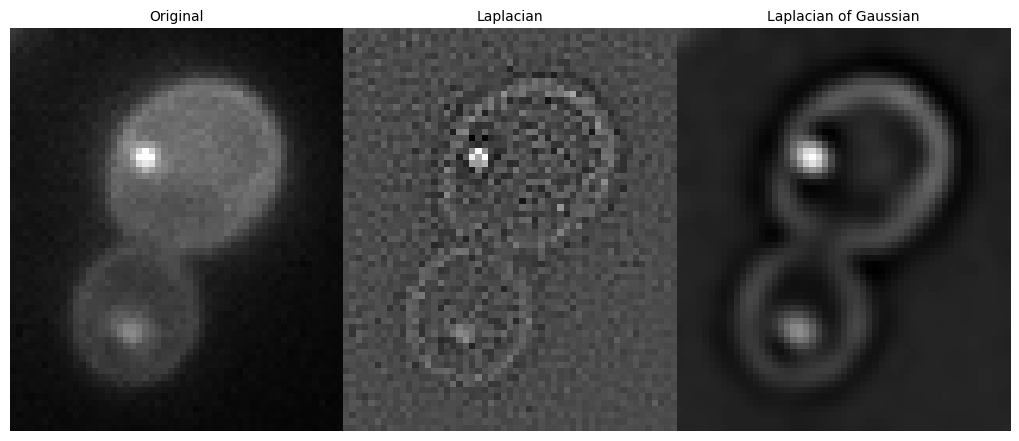

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img, ax=ax1, title="Original")
imshow(img_f_lp, ax=ax2, title="Laplacian")
imshow(img_f_log, ax=ax3, title="Laplacian of Gaussian")

### Linear vs. non-linear filters

In [45]:
img_orig = imread("cells_original.tif")
img_salt_pepper = imread("cells_salt_pepper.tif")
img_gauss = imread("cells_gaussian.tif")

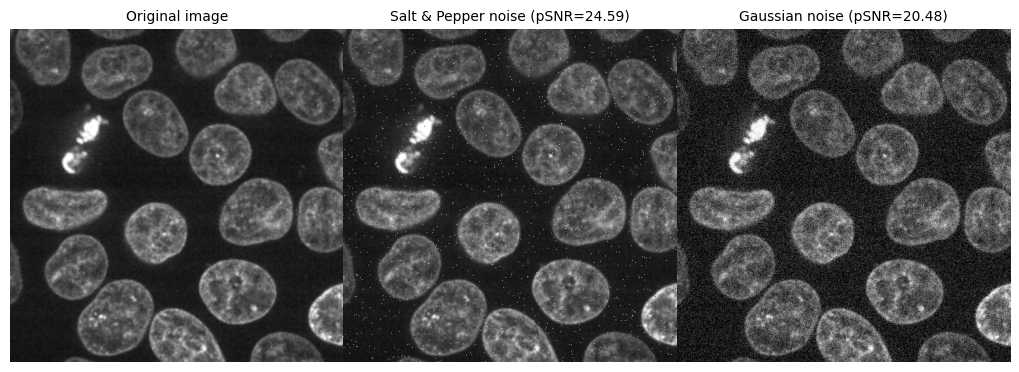

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img_orig, ax=ax1, title="Original image")
imshow(img_salt_pepper, ax=ax2, title=f"Salt & Pepper noise (pSNR={peak_signal_noise_ratio(img_salt_pepper, img_orig):.2f})")
imshow(img_gauss, ax=ax3, title=f"Gaussian noise (pSNR={peak_signal_noise_ratio(img_gauss, img_orig):.2f})")

In [47]:
med_filt_sp_img = median(img_salt_pepper, np.ones((3, 3)))
gauss_filt_sp_img = gaussian(img_salt_pepper, sigma=1.0, preserve_range=True).astype(np.uint16)

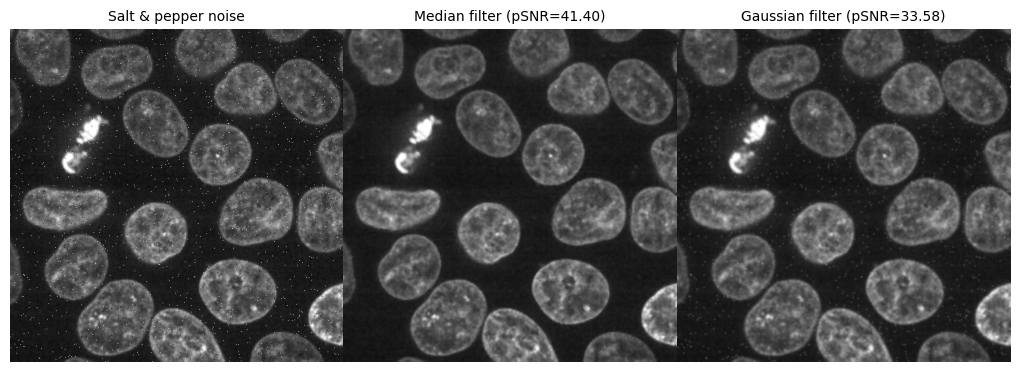

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img_salt_pepper, ax=ax1, title="Salt & pepper noise")
imshow(med_filt_sp_img, ax=ax2, title=f"Median filter (pSNR={peak_signal_noise_ratio(med_filt_sp_img, img_orig):.2f})")
imshow(gauss_filt_sp_img, ax=ax3, title=f"Gaussian filter (pSNR={peak_signal_noise_ratio(gauss_filt_sp_img, img_orig):.2f})")

In [49]:
med_filt_gs_img = median(img_gauss, np.ones((3, 3)))
gauss_filt_gs_img = gaussian(img_gauss, sigma=1.0, preserve_range=True).astype(np.uint16)

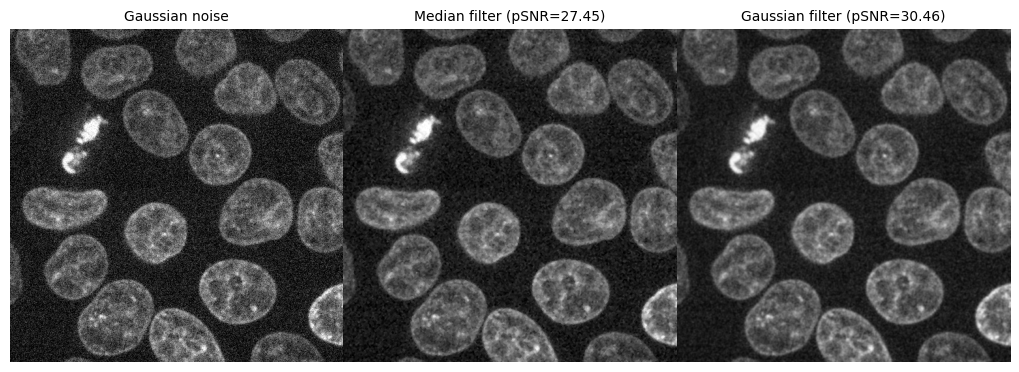

In [50]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
imshow(img_gauss, ax=ax1, title="Gaussian noise")
imshow(med_filt_gs_img, ax=ax2, title=f"Median filter (pSNR={peak_signal_noise_ratio(med_filt_gs_img, img_orig):.2f})")
imshow(gauss_filt_gs_img, ax=ax3, title=f"Gaussian filter (pSNR={peak_signal_noise_ratio(gauss_filt_gs_img, img_orig):.2f})")

## Segmentation

In [51]:
img = imread("neuron.tif")

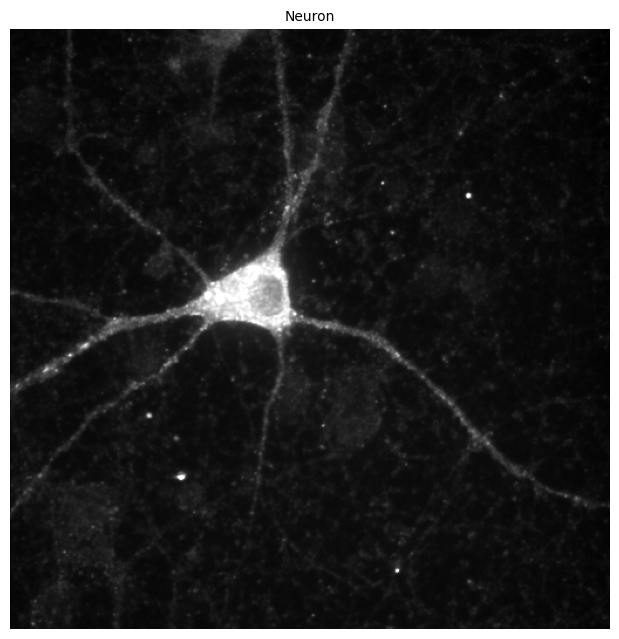

In [52]:
imshow(img, title="Neuron")

In [53]:
th_ot = threshold_otsu(img)
th_li = threshold_li(img)
th_tr = threshold_triangle(img)
print(th_ot, th_li, th_tr)

106 52.75411424529564 42


In [54]:
n, b = histogram(img, source_range="dtype")

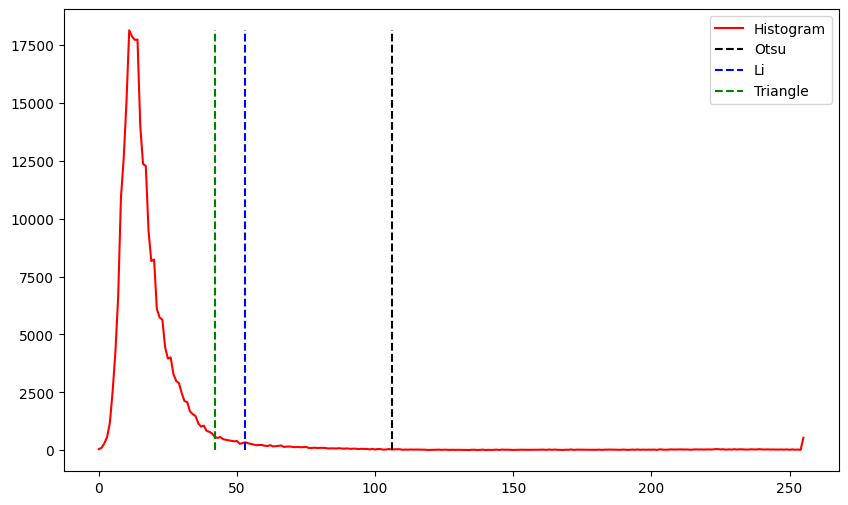

In [55]:
ax1 = plt.subplot()
l1, = ax1.plot(b, n, color="r")
l2, = ax1.plot([th_ot, th_ot], [0, n.max()], "k--")
l3, = ax1.plot([th_li, th_li], [0, n.max()], "b--")
l4, = ax1.plot([th_tr, th_tr], [0, n.max()], "g--")
plt.legend([l1, l2, l3, l4], ["Histogram", "Otsu", "Li", "Triangle"]);

In [56]:
bw_ot = img > th_ot
bw_li = img > th_li
bw_tr = img > th_tr

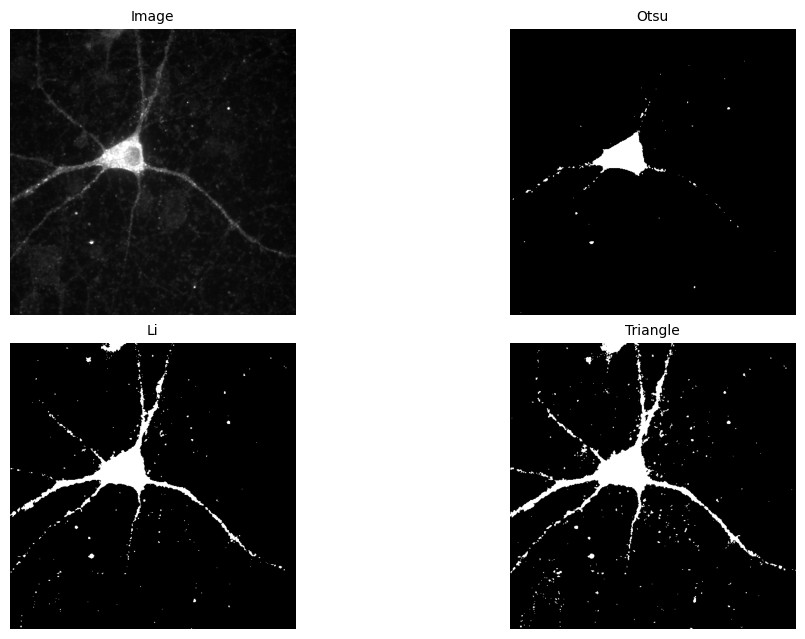

In [57]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
imshow(img, ax=ax1, title="Image")
imshow(bw_ot, ax=ax2, title="Otsu")
imshow(bw_li, ax=ax3, title="Li")
imshow(bw_tr, ax=ax4, title="Triangle")

## Background subtraction

In [58]:
img = imread("cells_shaded.tif")

In [59]:
th_ot = threshold_otsu(img)

In [60]:
bw_ot = img > th_ot

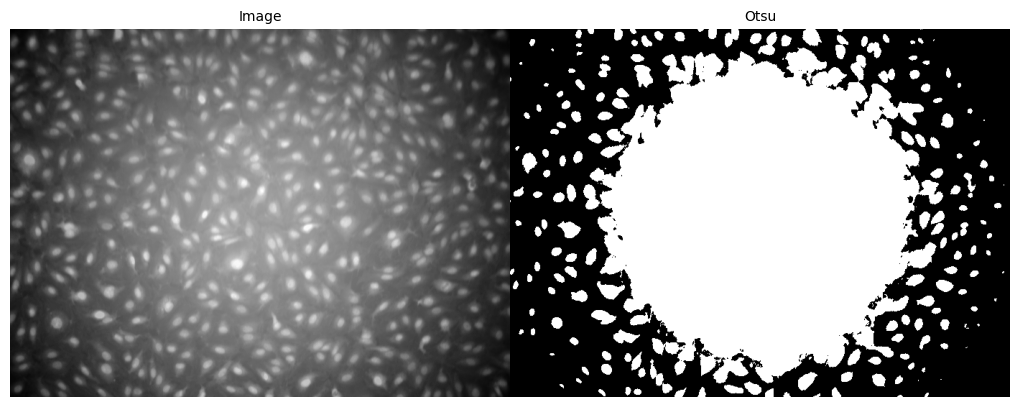

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2)
imshow(img, ax=ax1, title="Image")
imshow(bw_ot, ax=ax2, title="Otsu")

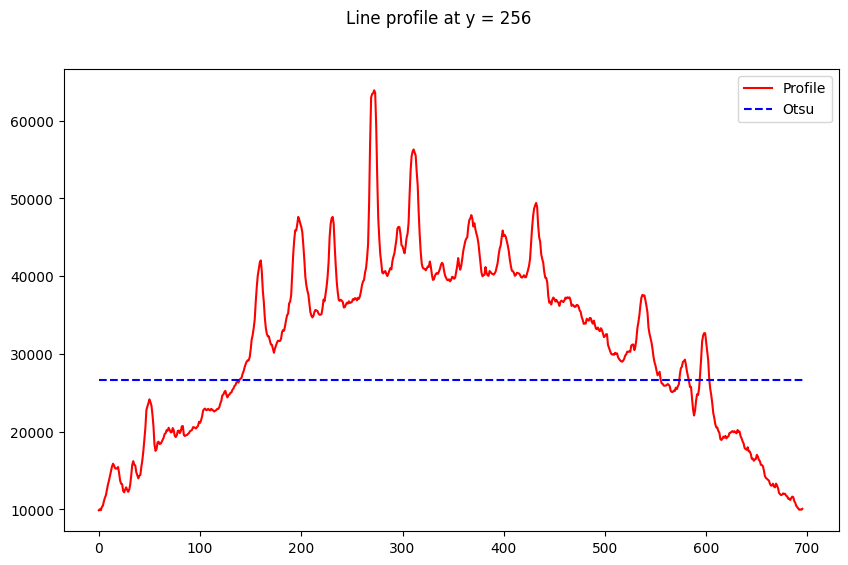

In [62]:
plt.plot(img[img.shape[0] // 2, :], 'r-', label="Profile")
plt.plot([0, img.shape[1]], [th_ot, th_ot], 'b--', label="Otsu")
plt.suptitle(f"Line profile at y = {img.shape[0] // 2}");
plt.legend();

In [63]:
img_corr, bkg = subtract_background(img, algorithm="morphological_opening", radius=25, return_background=True)  # Change `down_size_factor` for large images!

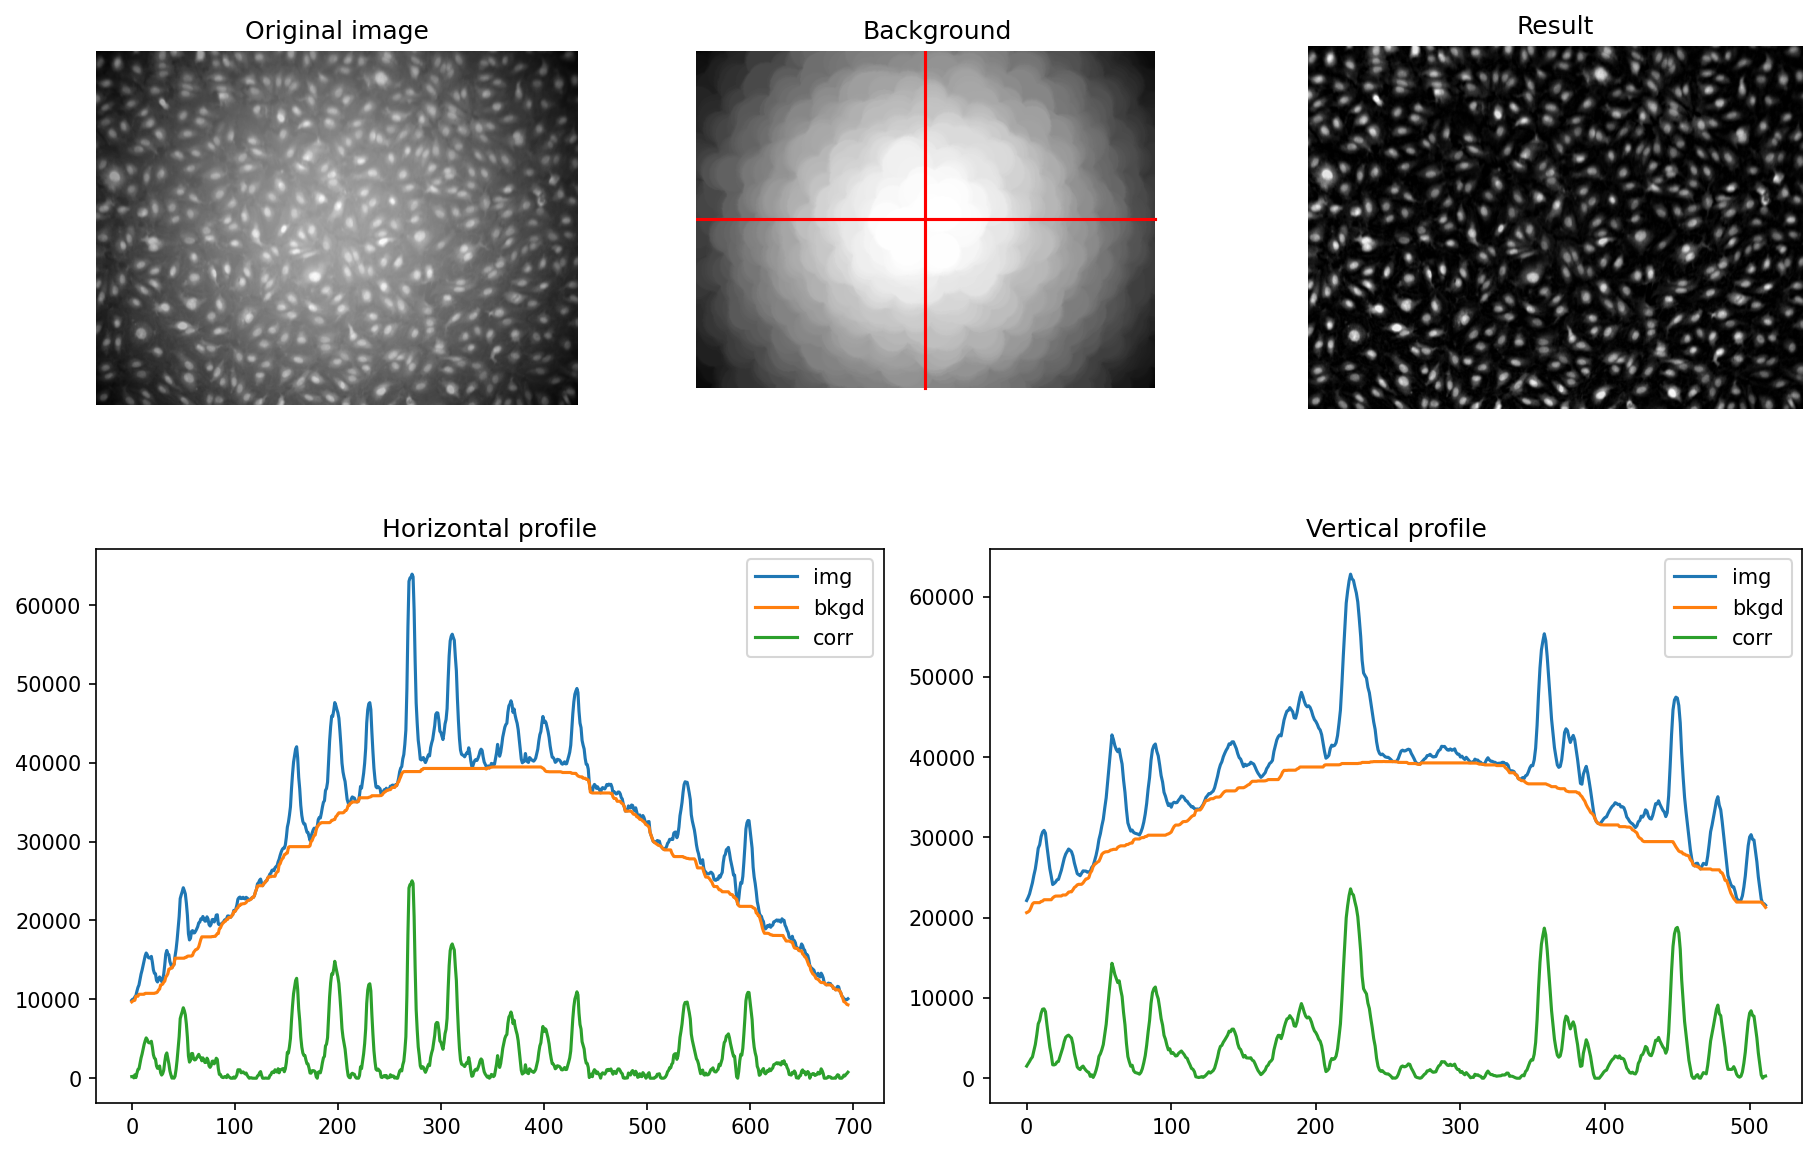

In [64]:
plot_background_subtraction_control(img, bkg)

In [65]:
th_ot_corr = threshold_otsu(img_corr)

In [66]:
bw_ot_corr = img_corr > th_ot_corr

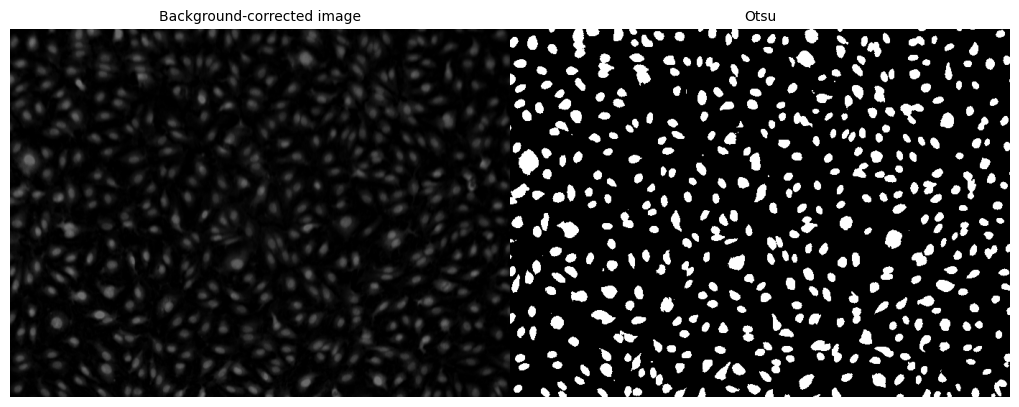

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2)
imshow(img_corr, ax=ax1, title="Background-corrected image")
imshow(bw_ot_corr, ax=ax2, title="Otsu")

## Connected components

In [68]:
bw = imread("connected_components.tif")

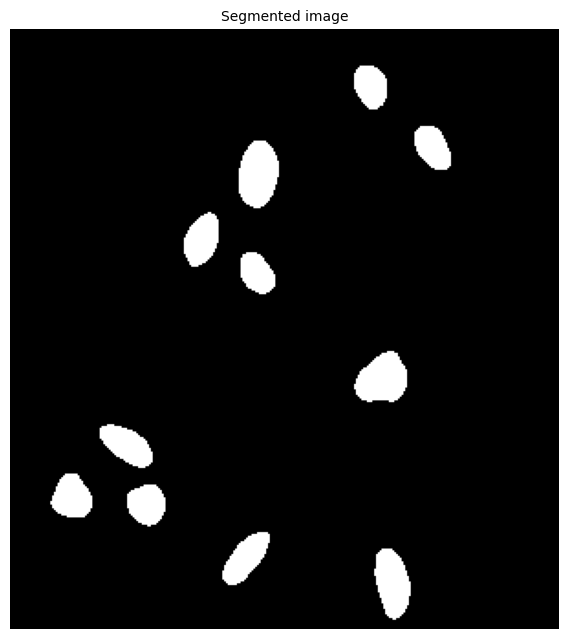

In [69]:
imshow(bw, title="Segmented image")

In [70]:
labels, num = label(bw, background=0, return_num=True, connectivity=1)
print(f"Found {num} objects.")

Found 11 objects.


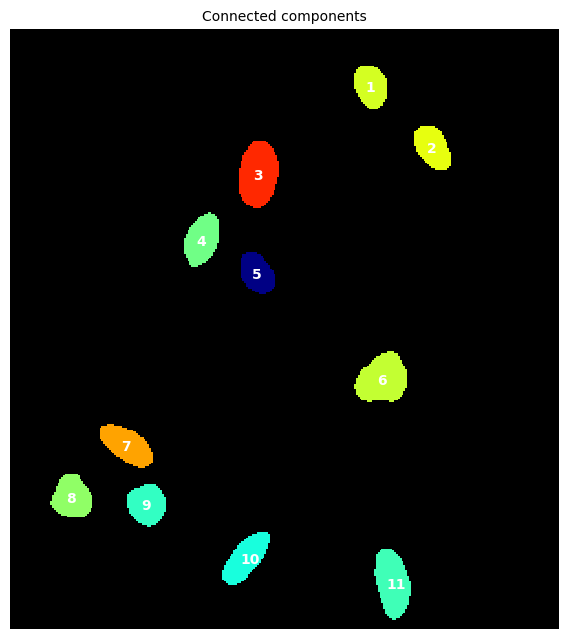

In [71]:
show_labels(labels, plot_labels=True, title="Connected components")

## Watershed segmentation

In [72]:
bw = imread("watershed.tif")

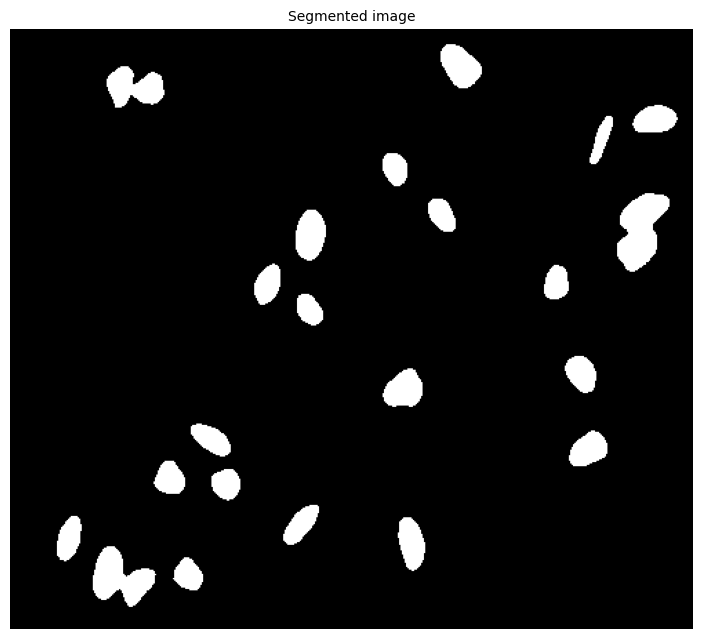

In [73]:
imshow(bw, title="Segmented image")

In [74]:
labels, num = label(bw, background=0, return_num=True, connectivity=1)
print(f"Found {num} objects.")

Found 22 objects.


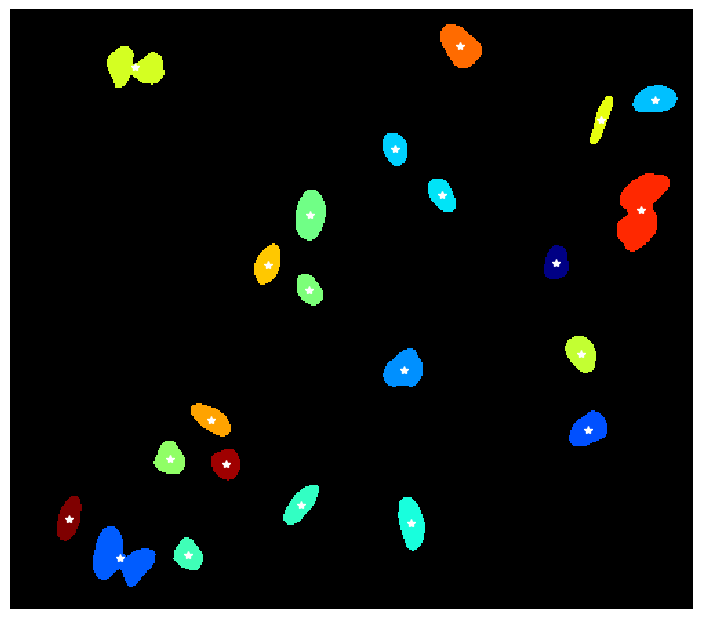

In [75]:
show_labels(labels, plot_centroids=True)

In [76]:
_, min_axis, _, _ = estimate_object_sizes(labels)

In [77]:
labels_sep, num_sep, _ = separate_neighboring_objects(bw, labels, min_size=min_axis)
print(f"Found {num_sep} objects.")

Found 25 objects.


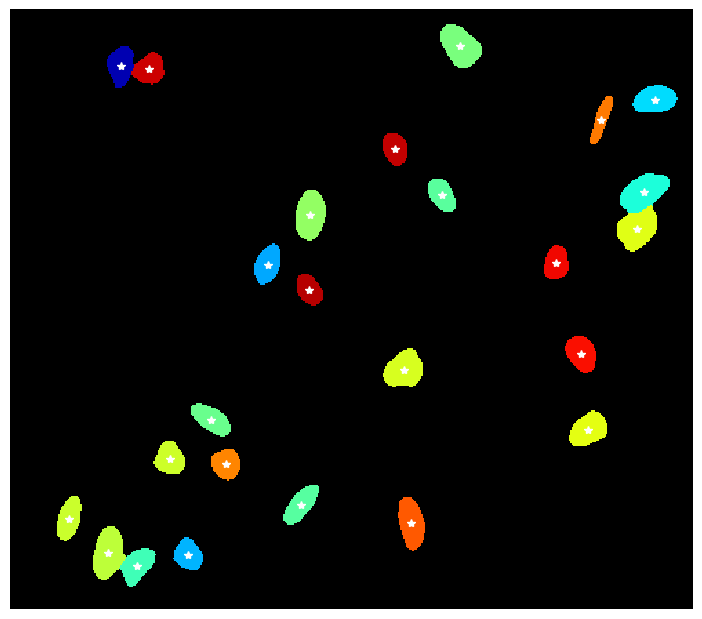

In [78]:
show_labels(labels_sep, plot_centroids=True)

## Morphological operations

In [79]:
bw = imread("actin_bad_segmentation.tif")

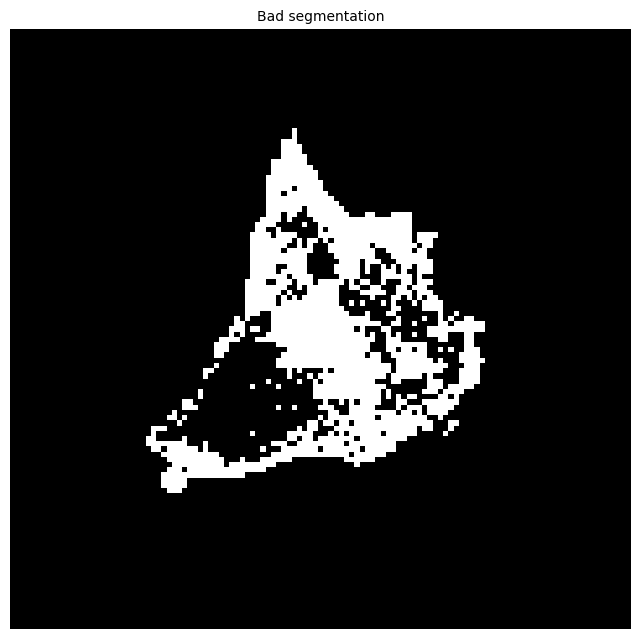

In [80]:
imshow(bw, title="Bad segmentation")

In [81]:
labels, num = label(bw, background=0, return_num=True, connectivity=1)
print(f"Found {num} objects.")

Found 42 objects.


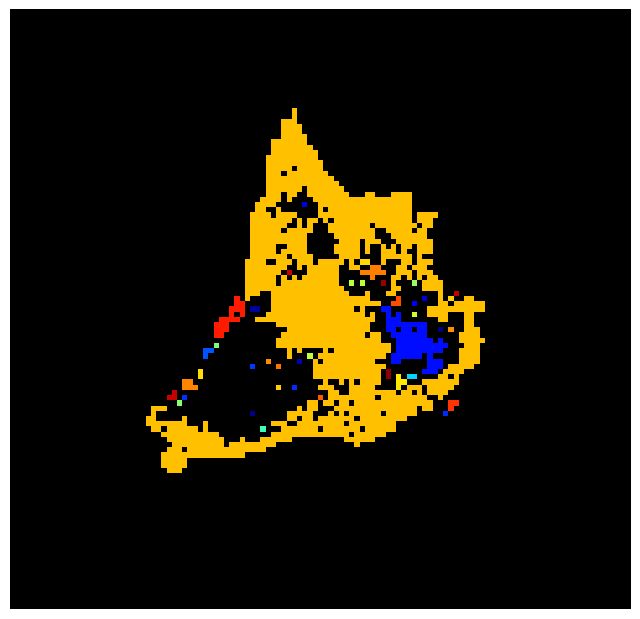

In [82]:
show_labels(labels)

In [83]:
strel = disk(1)
dilated = dilation(bw, strel)

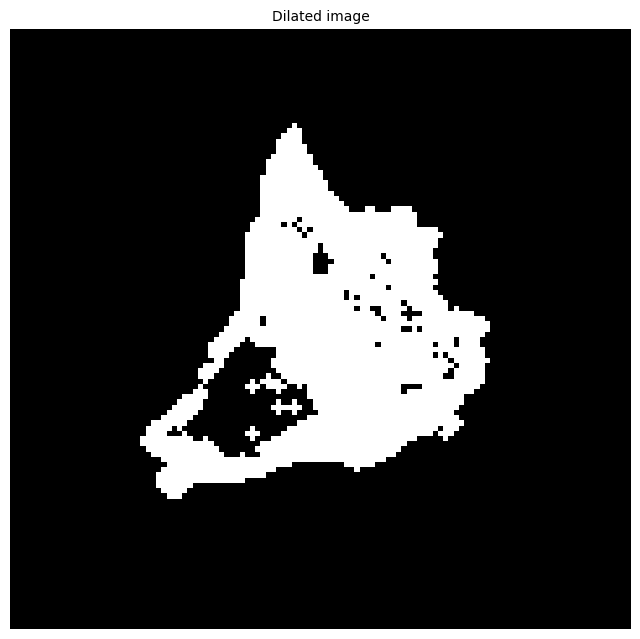

In [84]:
imshow(dilated, title="Dilated image")

In [85]:
filled = binary_fill_holes(dilated)

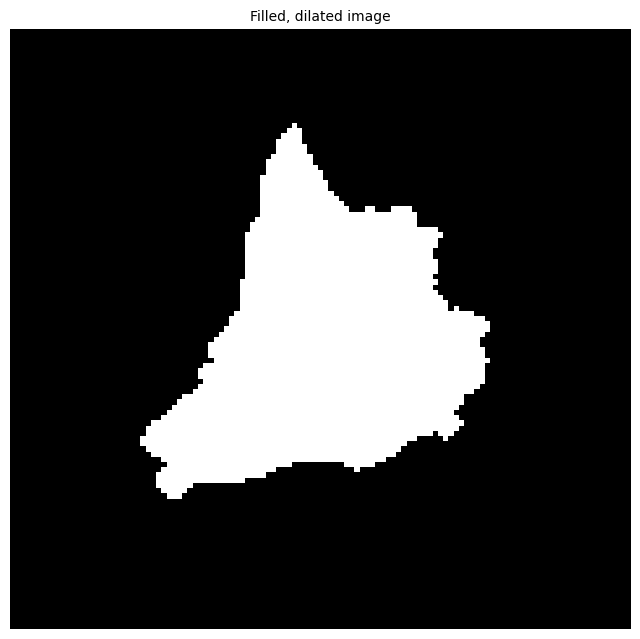

In [86]:
imshow(filled, title="Filled, dilated image")

In [87]:
eroded = erosion(filled, strel)

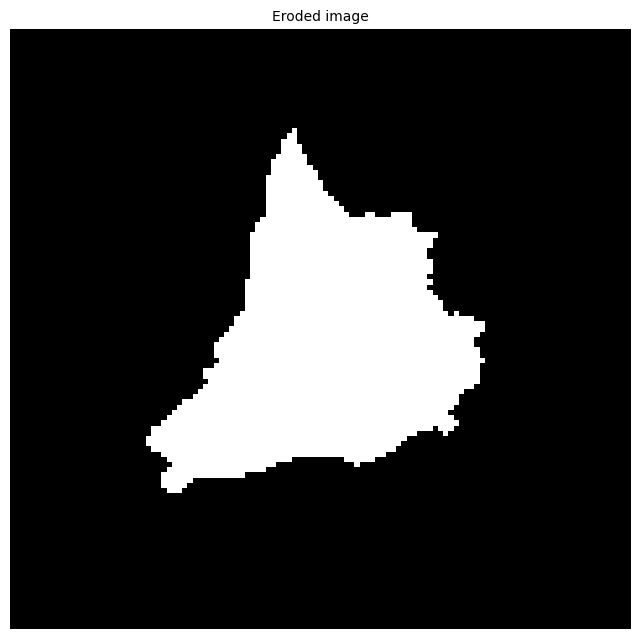

In [88]:
imshow(eroded, title="Eroded image")

In [89]:
labels, num = label(eroded, background=0, return_num=True, connectivity=1)
print(f"Found {num} object.")

Found 1 object.


## Measurements

In [90]:
img = imread("regions.tif")
labels = imread("regions_labels.tif")

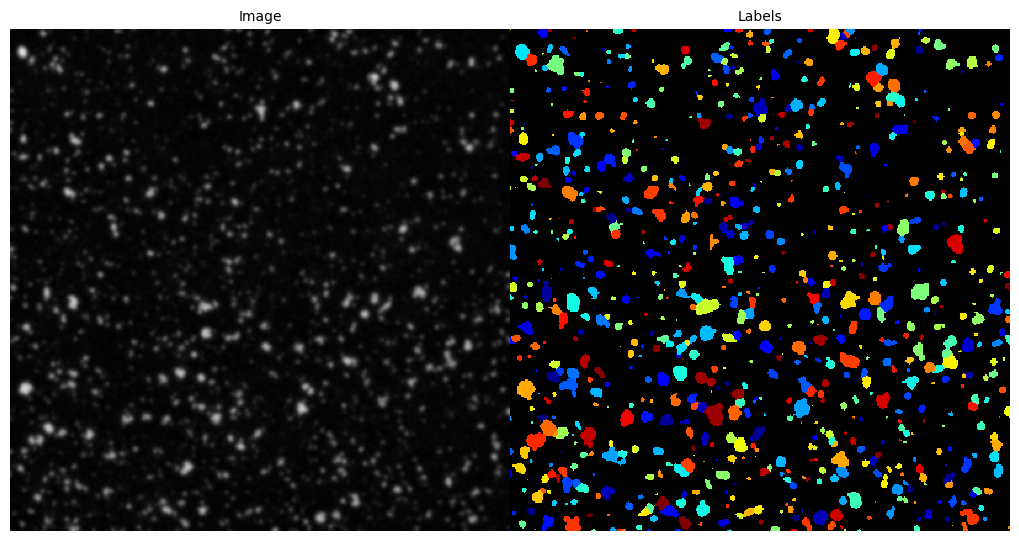

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2)
imshow(img, ax=ax1, title="Image")
show_labels(labels, ax=ax2, title="Labels")

In [92]:
props = regionprops(labels, intensity_image=img)

In [93]:
for prop in props:
    print(f"label={prop.label:2}: area={prop.area:3}, centroid=(x={prop.centroid[0]:6.2f}, y={prop.centroid[1]:6.2f}), mean intensity={prop.intensity_mean:6.2f}")
    if prop.label > 9:
        break

label= 1: area=3.0, centroid=(x=  0.33, y=  0.33), mean intensity= 37.33
label= 2: area=2.0, centroid=(x=  0.00, y= 74.50), mean intensity= 24.00
label= 3: area=37.0, centroid=(x=  1.84, y= 87.43), mean intensity= 46.97
label= 4: area=14.0, centroid=(x=  0.79, y=100.21), mean intensity= 41.07
label= 5: area=4.0, centroid=(x=  0.00, y=134.50), mean intensity= 29.50
label= 6: area=25.0, centroid=(x=  0.92, y=176.48), mean intensity= 54.16
label= 7: area=21.0, centroid=(x=  1.14, y=185.33), mean intensity= 48.95
label= 8: area=1.0, centroid=(x=  0.00, y=201.00), mean intensity= 27.00
label= 9: area=30.0, centroid=(x=  2.33, y=208.53), mean intensity= 43.30
label=10: area=18.0, centroid=(x=  0.94, y=243.67), mean intensity= 49.00


In [94]:
def intensity_median(regionmask, intensity):
    return np.median(intensity[regionmask])

`extra_properties`: tuple of callables (functions). A property computation function must take a region mask as its first argument. If the property requires an intensity image, it must accept the intensity image as the second argument.

In [95]:
props = regionprops_table(labels, intensity_image=img, properties=('label', "area", "centroid", "intensity_mean"), extra_properties=(intensity_median,))

In [96]:
df = pd.DataFrame(props)

In [97]:
df.head()

,label,area,centroid-0,centroid-1,intensity_mean,intensity_median
0,1,3.0,0.333333,0.333333,37.333333,35.0
1,2,2.0,0.000000,74.500000,24.000000,24.0
2,3,37.0,1.837838,87.432432,46.972973,46.0
3,4,14.0,0.785714,100.214286,41.071429,40.0
4,5,4.0,0.000000,134.500000,29.500000,29.5


In [98]:
n, b = histogram(props["intensity_median"])

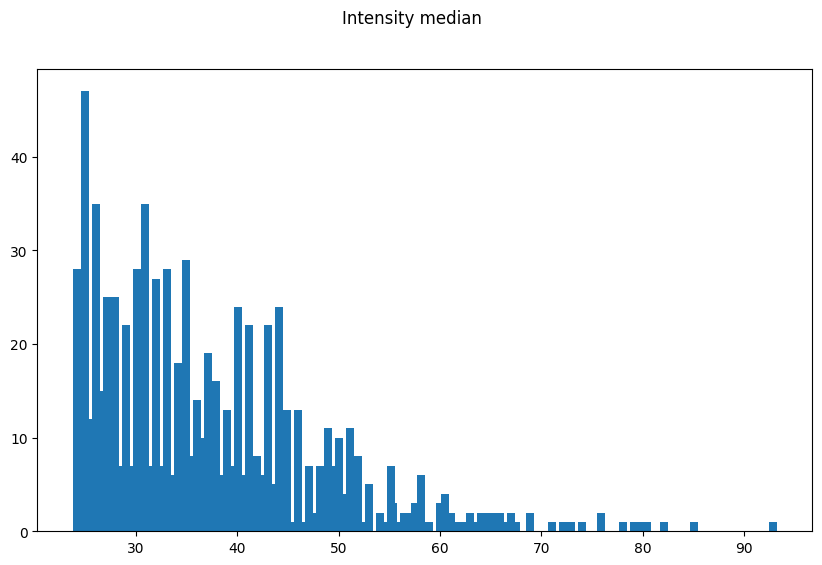

In [99]:
plt.bar(b, n)
plt.suptitle("Intensity median");